In [8]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
demographics = [
        "age",
        "gender",
        "religion",
        "ethnicity",
        "employment_status",
        "education",
        "birth_region",
        "reside_region",
        "marital_status",
        "english_proficiency",
    ]

In [3]:
def prepare_df(results):
    df = pd.DataFrame(results)
    df = df.T
    df = df.stack()
    df = df.reset_index()
    df = df.rename(columns={"level_0": "demographic", "level_1": "layer"})
    acc = (
        pd.DataFrame(df[0].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "acc"})
    )
    acc["acc"] = acc["acc"].mul(100)
    df = pd.merge(df, acc, left_index=True, right_on=["level_0"]).drop(
        columns=[0, "level_0"]
    )
    return df

In [31]:
with open(f"results/OLMo-2-1124-7B-Instruct_probe_results.pkl", "rb") as infile:
    olmo_probe = pickle.load(infile)

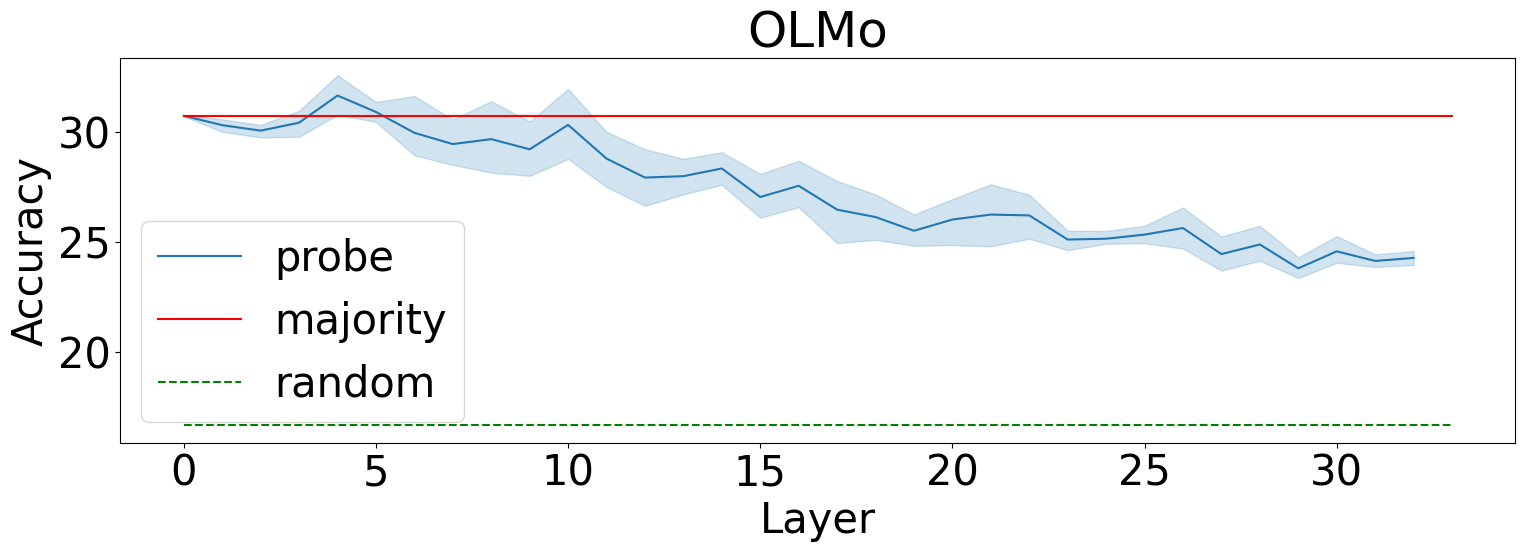

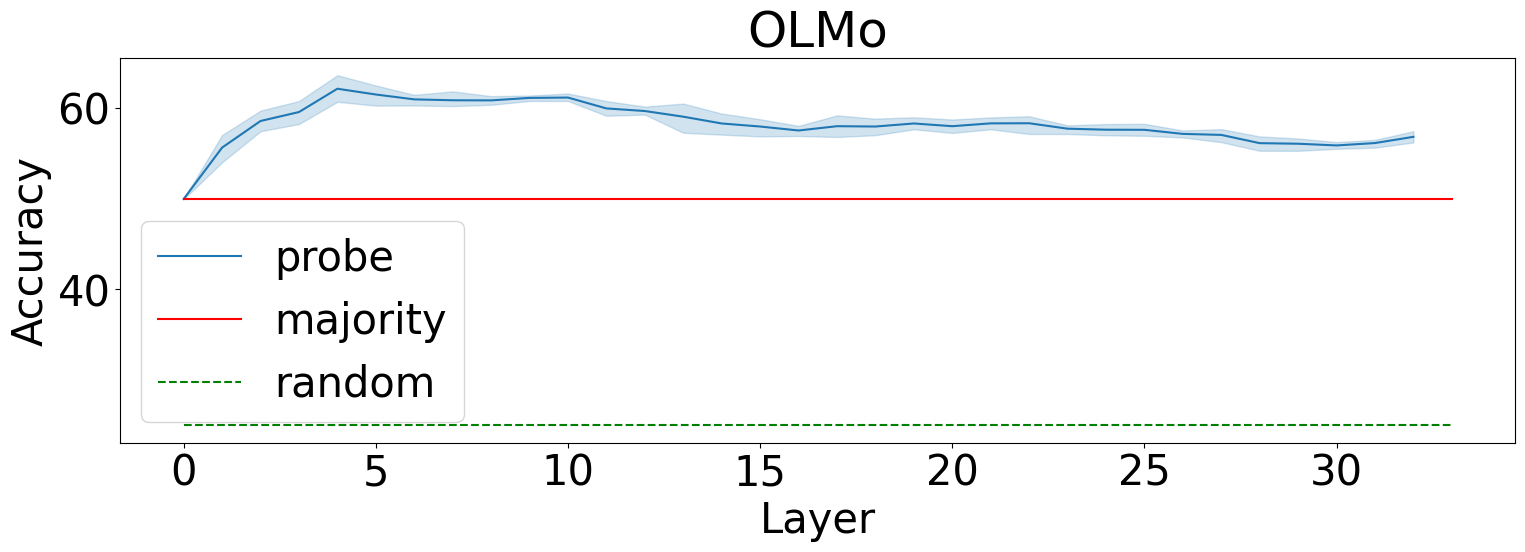

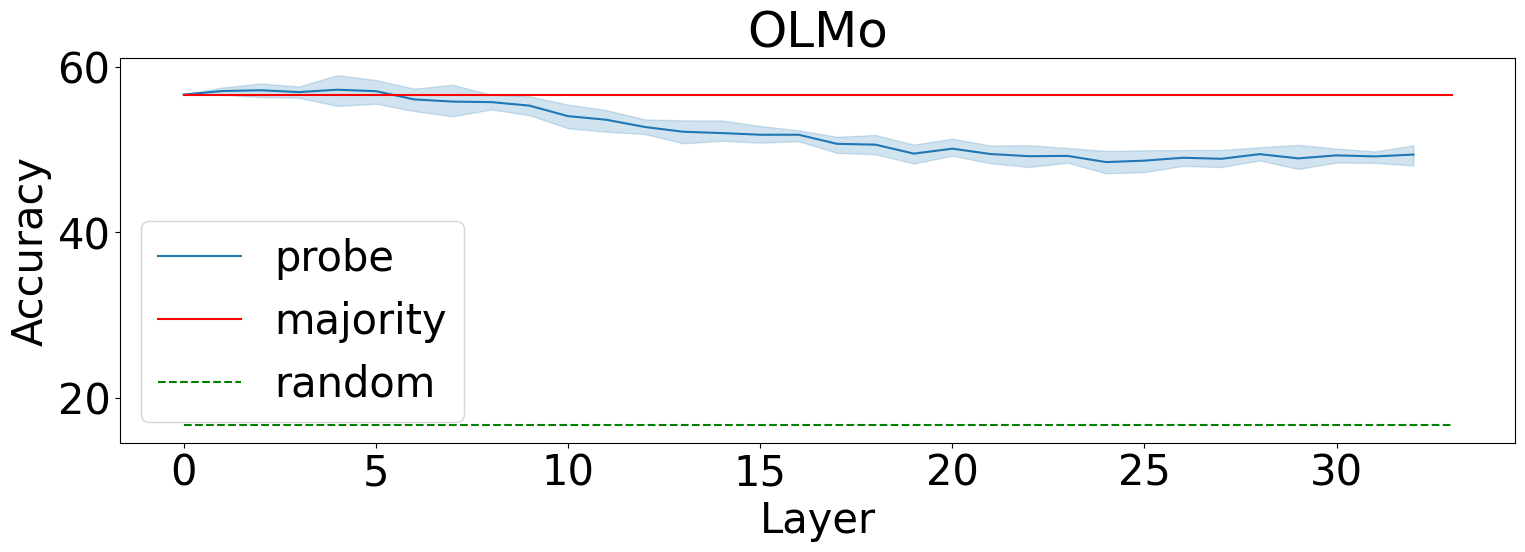

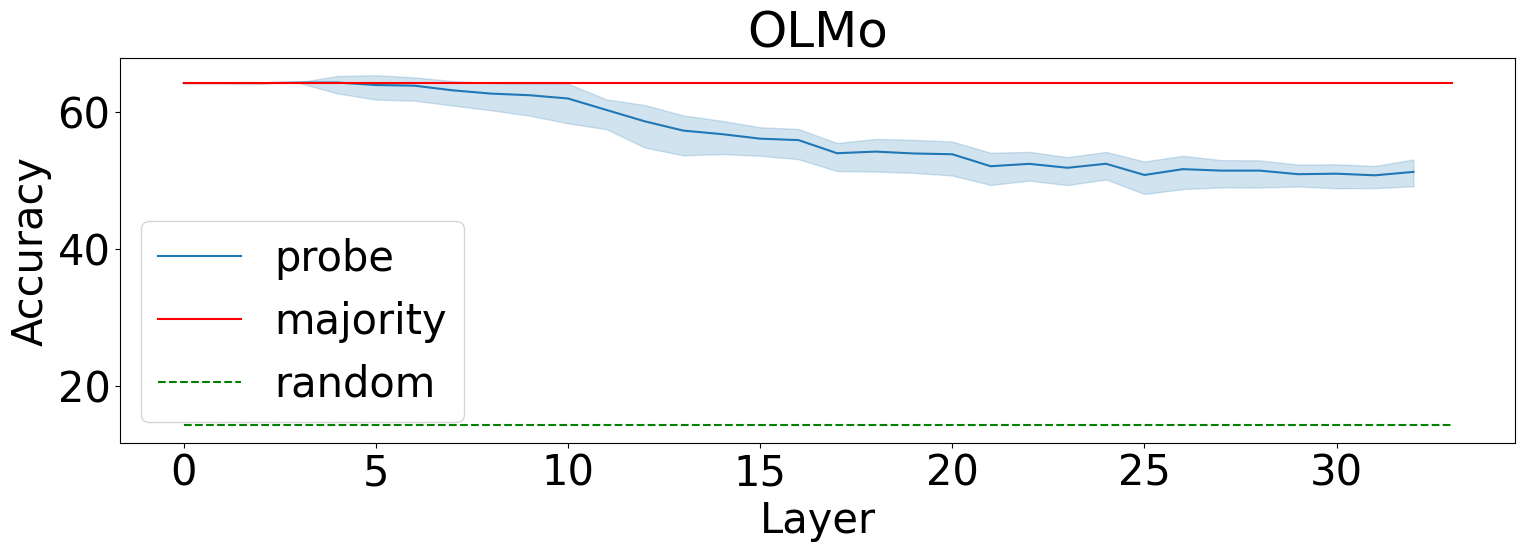

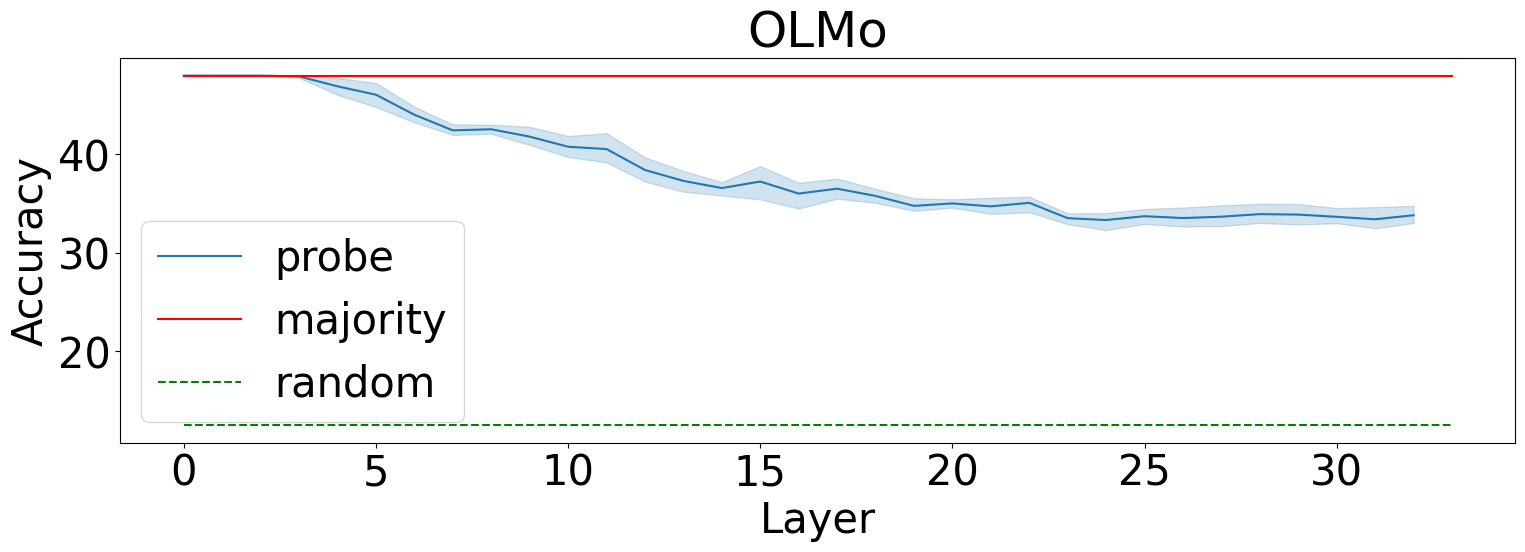

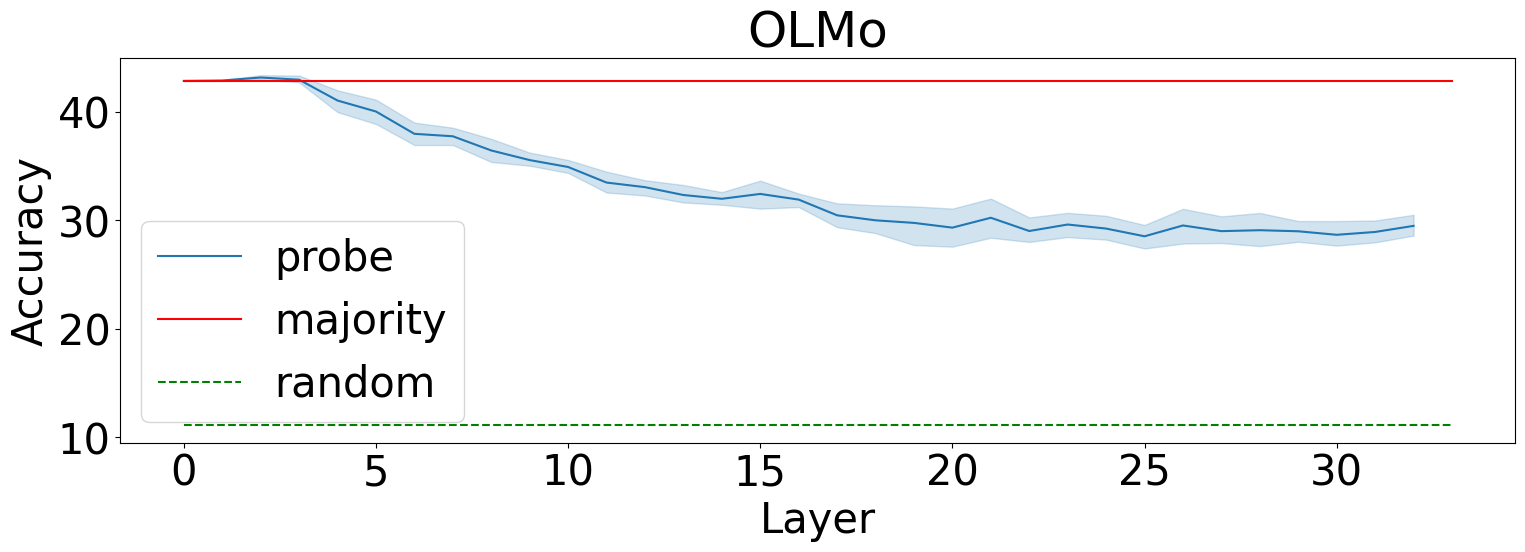

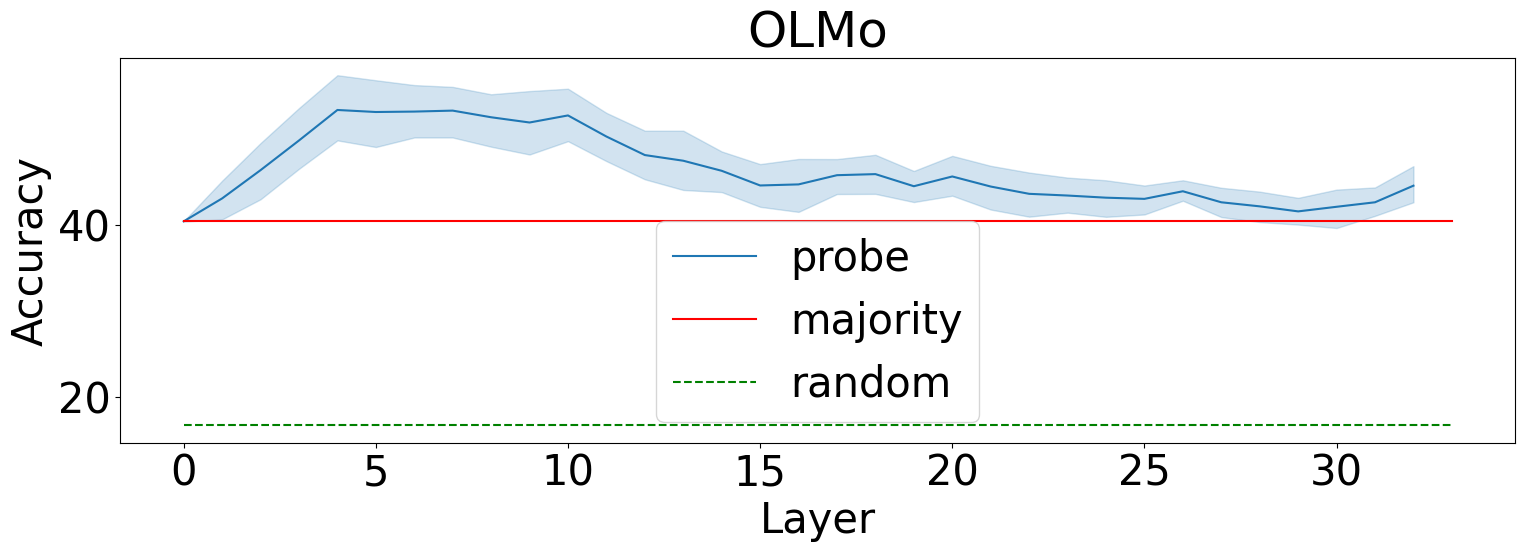

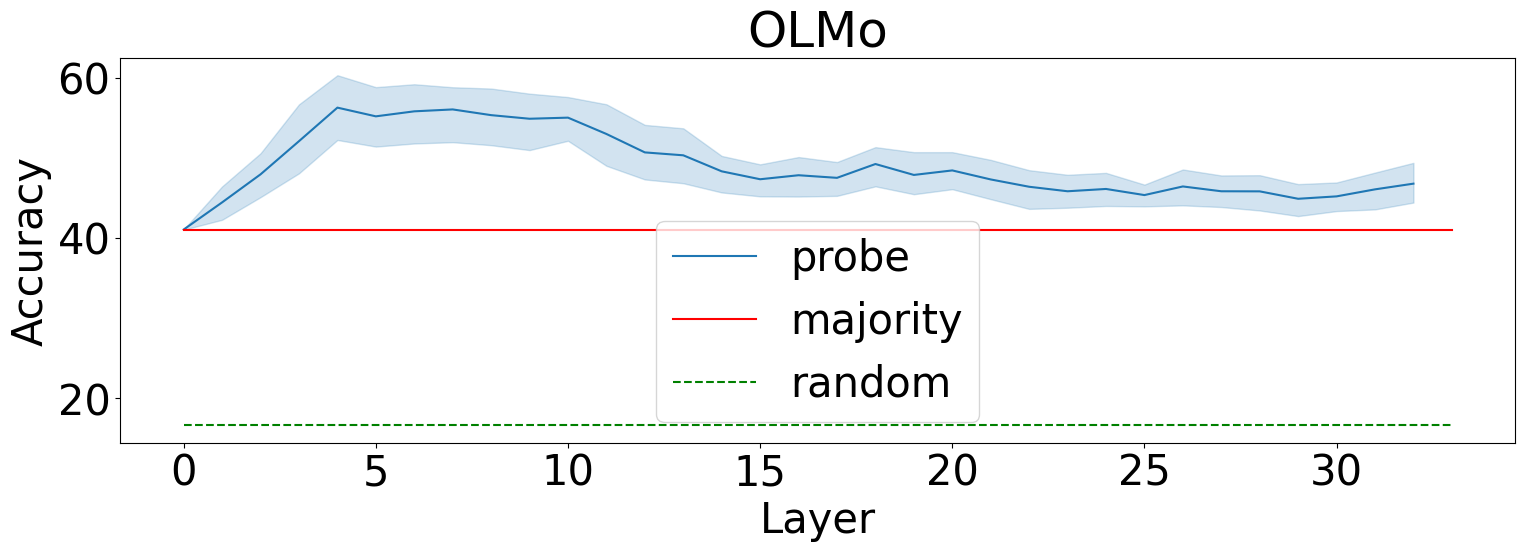

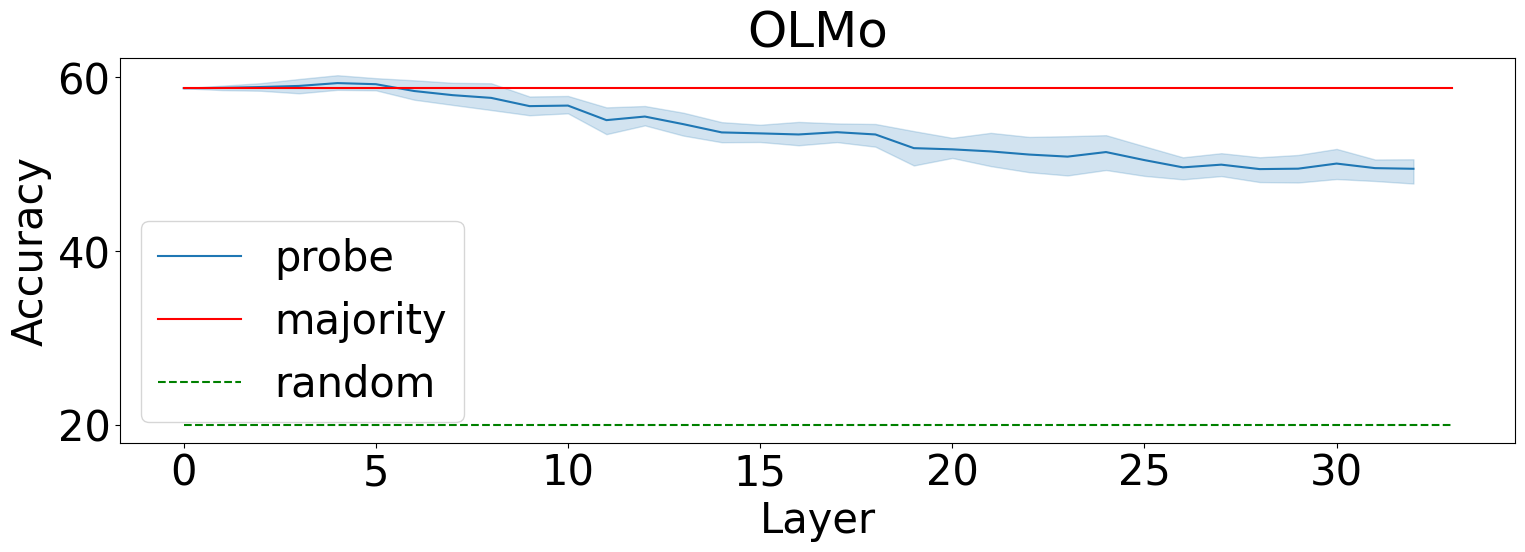

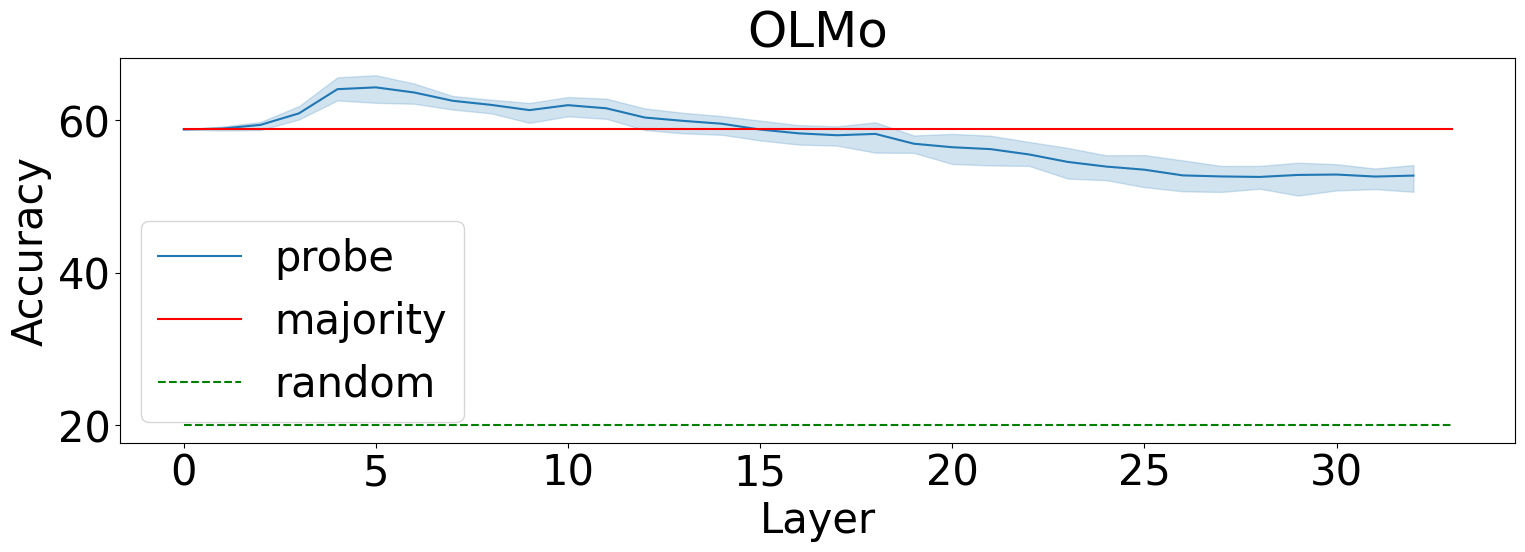

In [39]:
plt.rcParams.update({"font.size": 30})
model_results = {
    "OLMo": olmo_probe,
}
for model in model_results:
    results = model_results[model]
    df = prepare_df(results)
    model_results[model] = df

for demographic in demographics:
    fig, axes = plt.subplots(1, len(model_results), sharex=False, sharey=True, figsize=(18, 5))
    for i, model in enumerate(model_results):
        df = model_results[model]
        sns.lineplot(
            data=df[df["demographic"] == demographic],
            x="layer",
            y="acc",
            ax=axes,
            label="probe"
            #ax=axes[i],
        )
        plt.plot([0,33],[baselines[demographic][0],baselines[demographic][0]], color='r', linestyle='-', label="majority")
        plt.plot([0,33],[baselines[demographic][1],baselines[demographic][1]], color='g', linestyle='--', label="random")
        plt.legend(loc="best")
        #plt.ylim(0, 105)
        #axes.xaxis.set_major_locator(ticker.MultipleLocator(10))
        #axes.yaxis.set_major_locator(ticker.MultipleLocator(10))
        axes.set_title(model)
        axes.set_ylabel("Accuracy")
        axes.set_xlabel("Layer")
        # axes[i].xaxis.set_major_locator(ticker.MultipleLocator(10))
        # axes[i].set_title(model)
        # axes[i].set_ylabel("Accuracy")
        # axes[i].set_xlabel("Layer")
    plt.show()

In [29]:
olmo_answers = pd.read_pickle("results/OLMo-2-1124-7B-Instruct_answers.gz", compression="gzip")

In [33]:
baselines = {}
for demographic in demographics:
    baselines[demographic] = ((olmo_answers[demographic].value_counts().max()/len(olmo_answers)) * 100,100/len(olmo_answers[demographic].unique()))

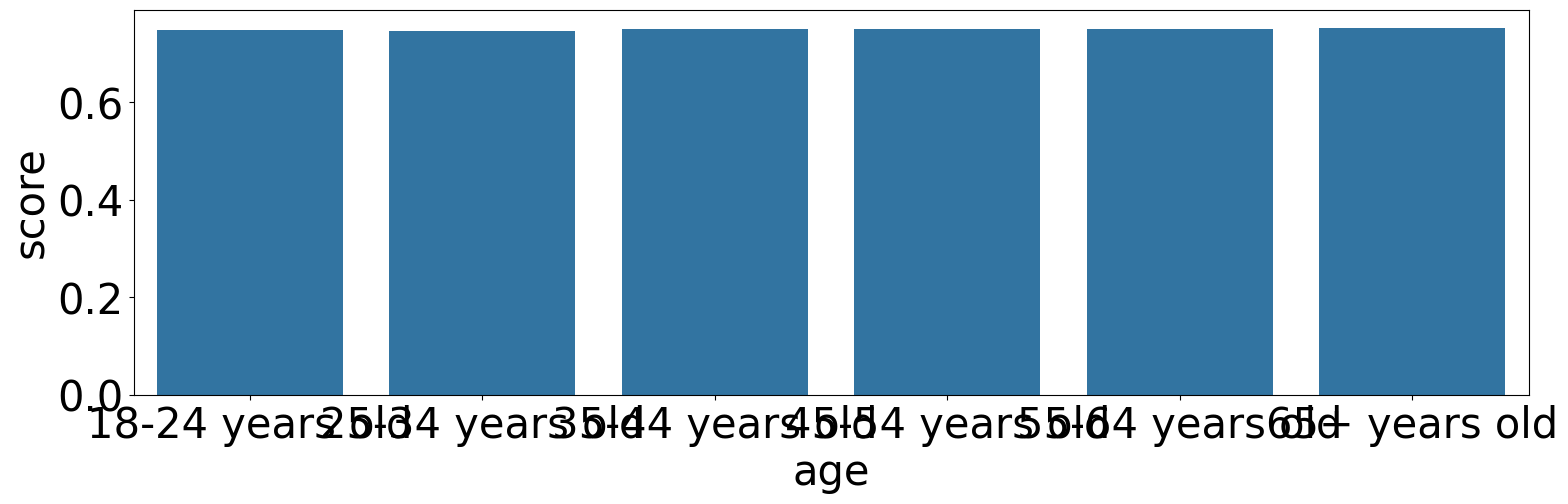

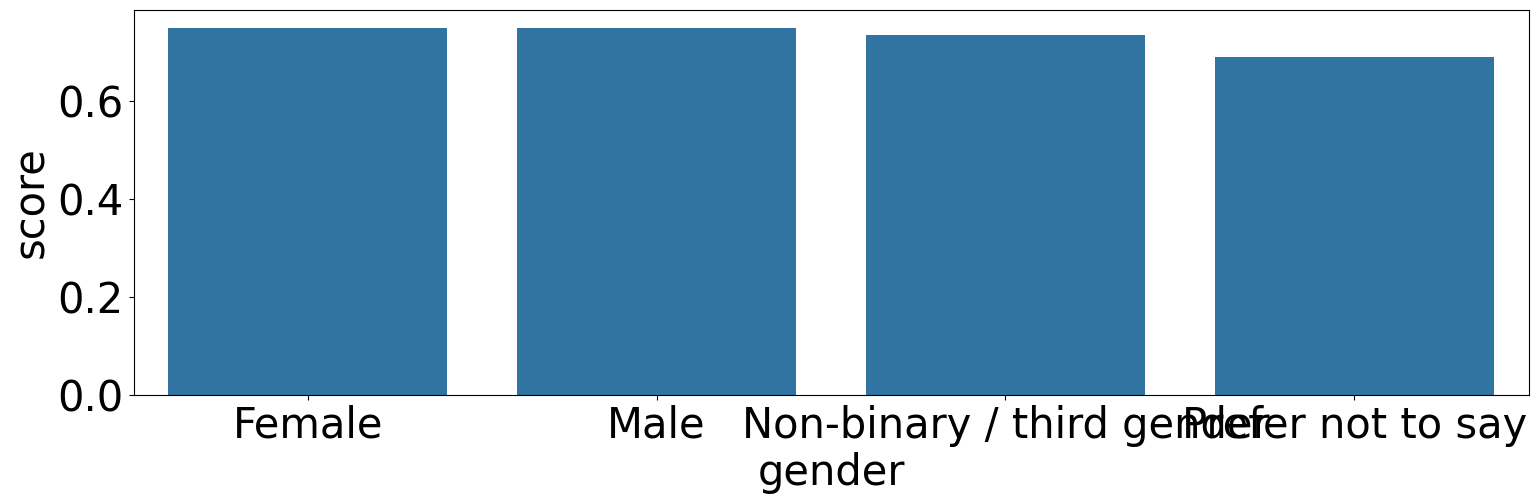

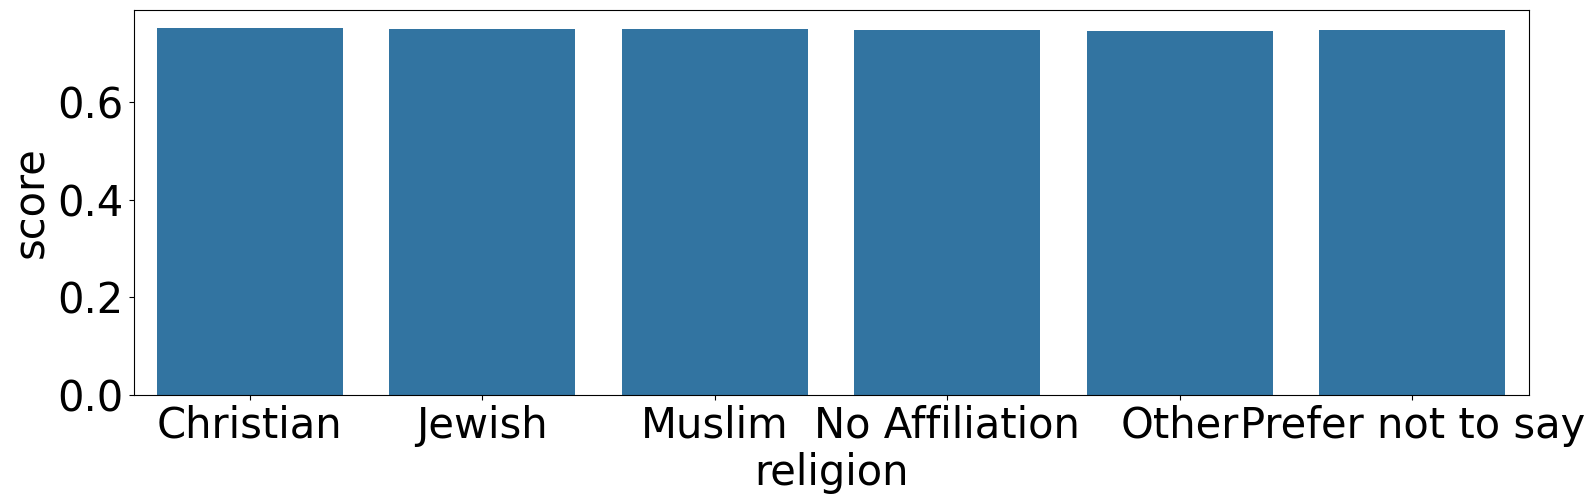

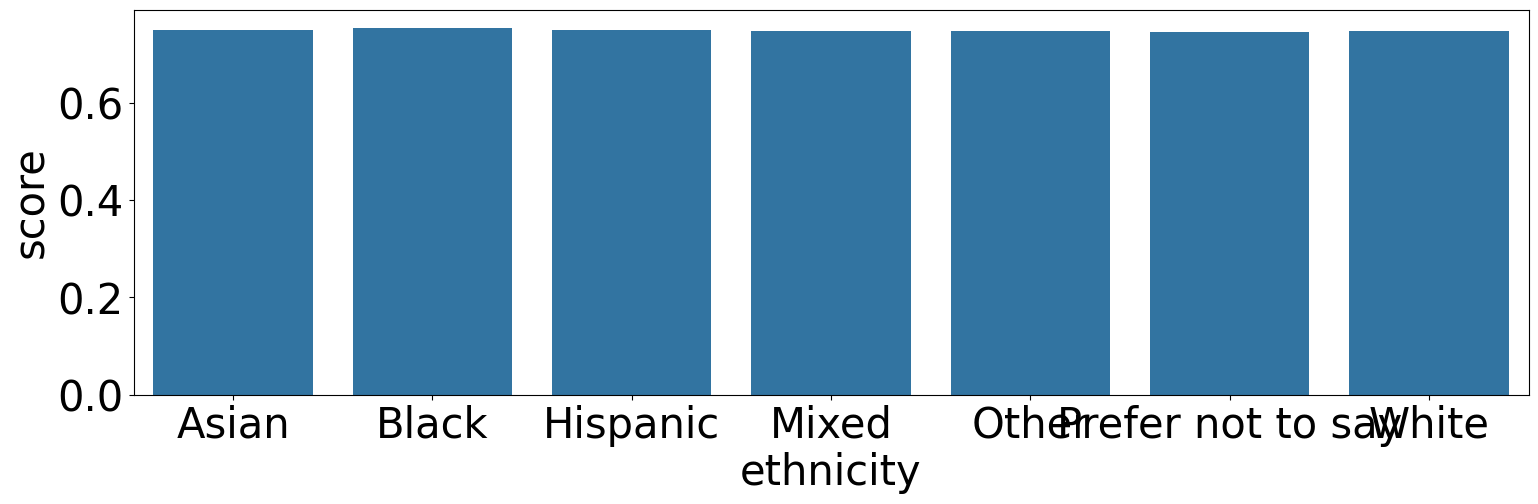

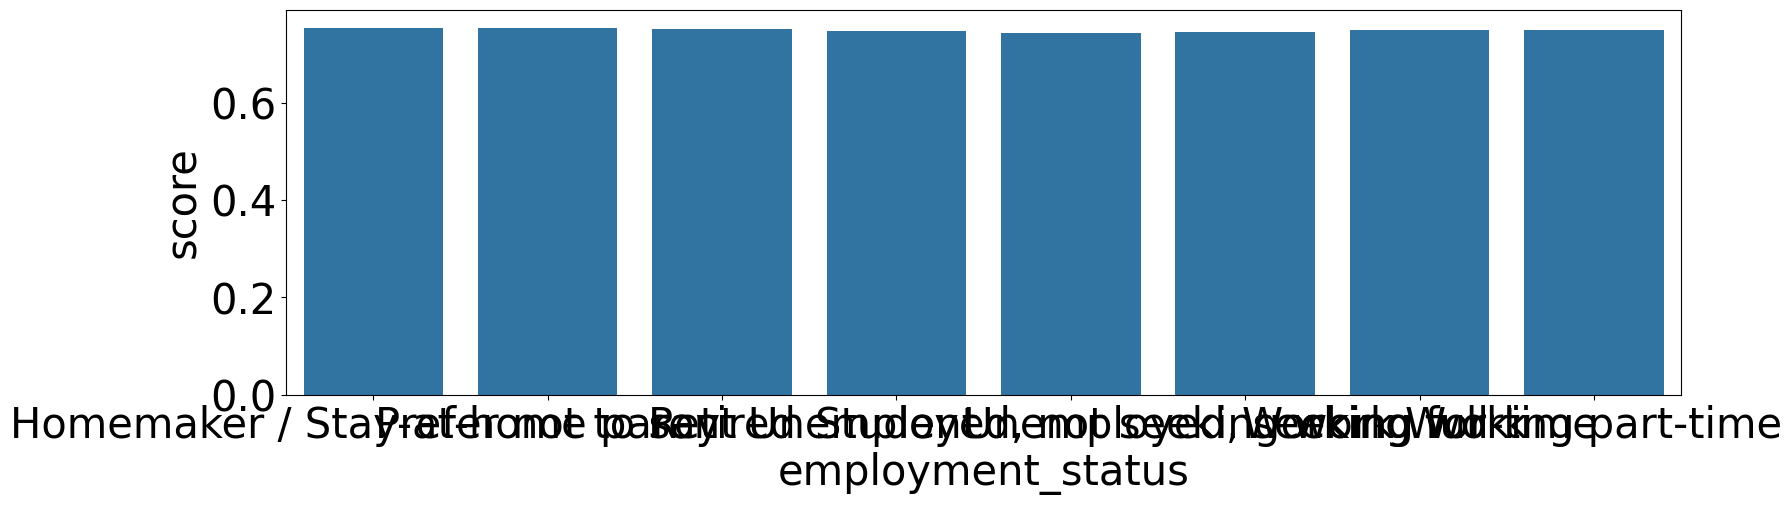

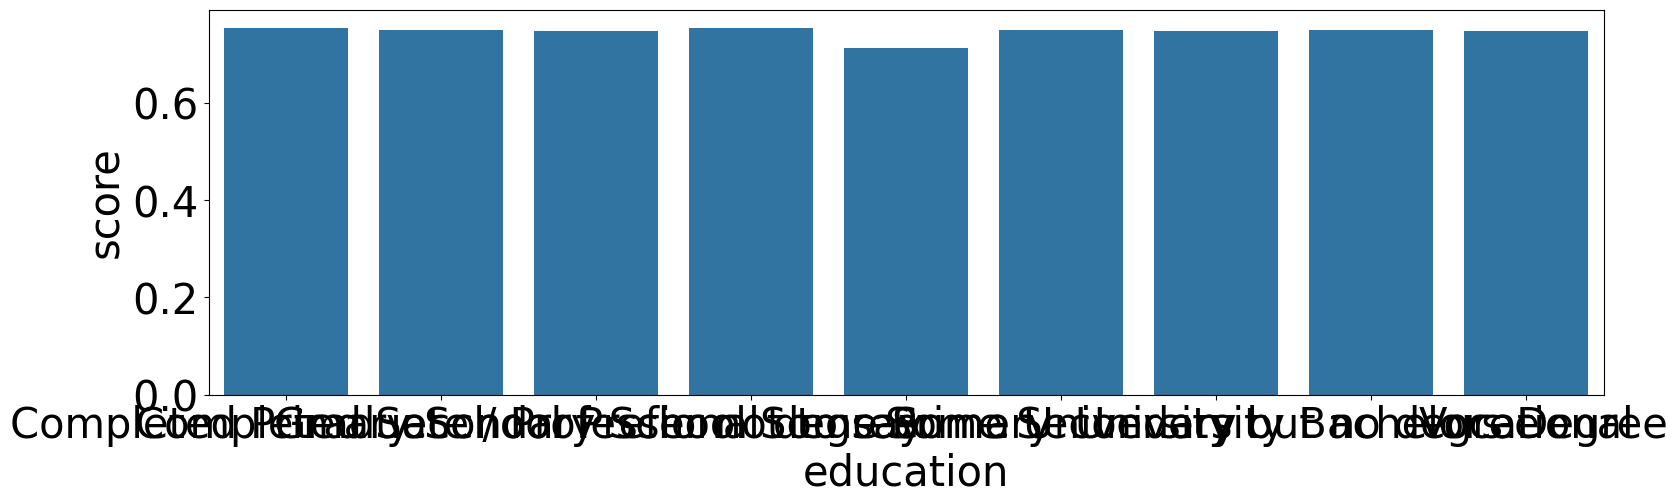

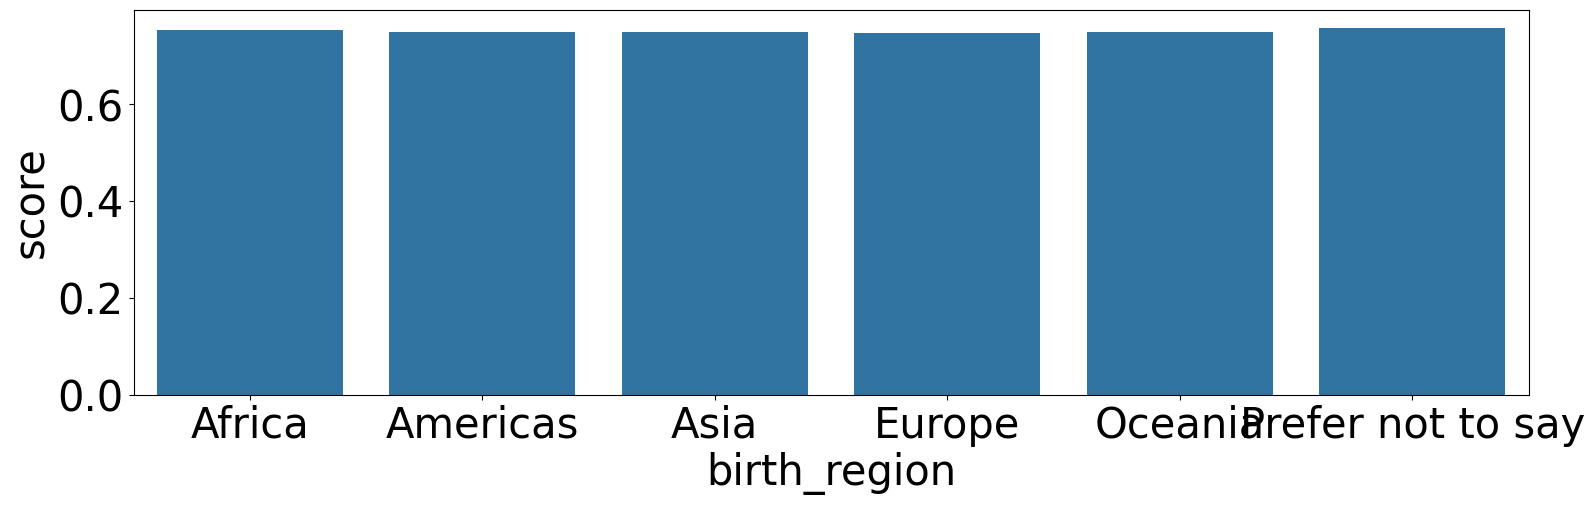

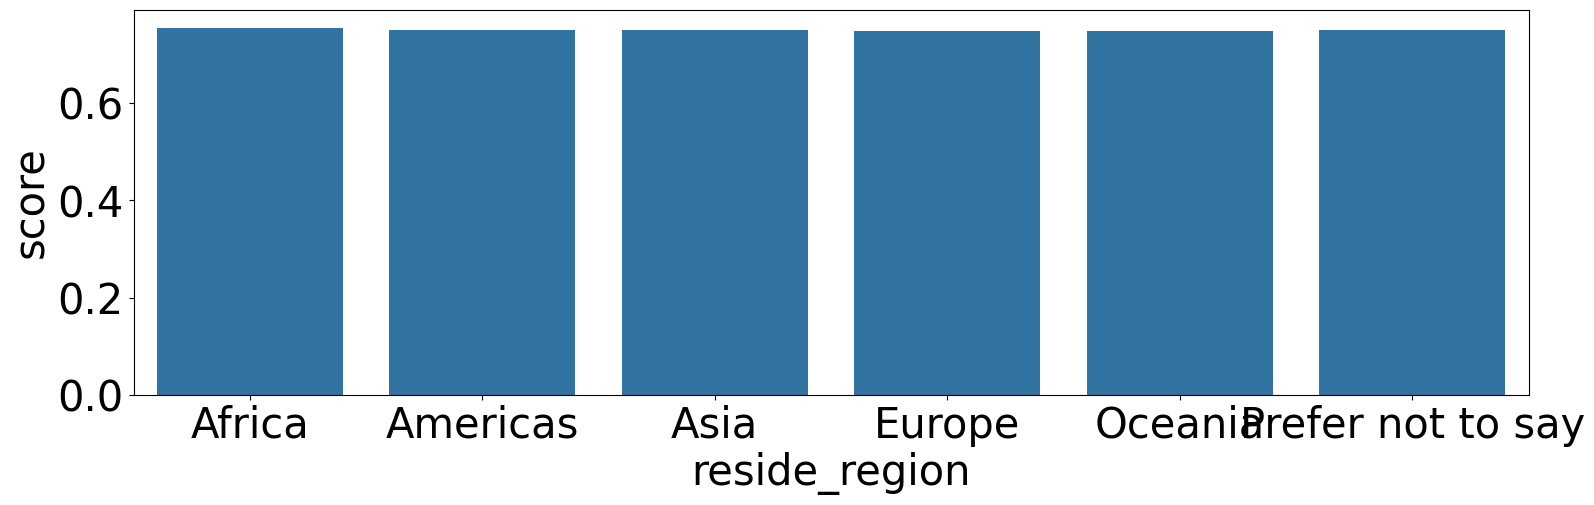

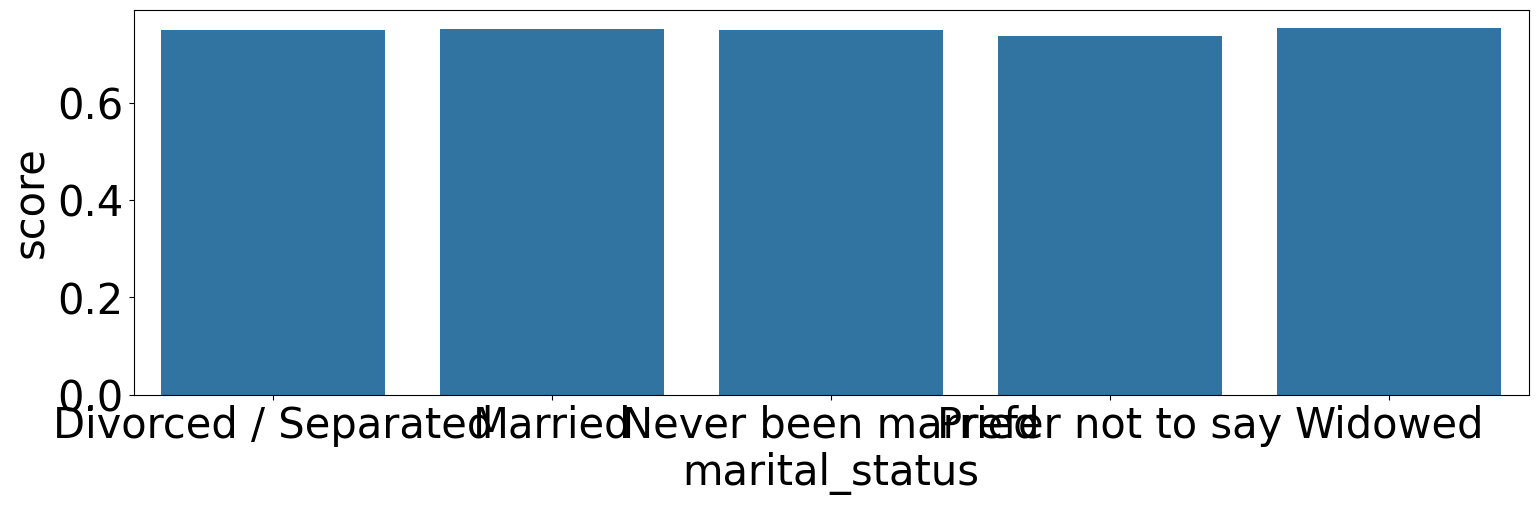

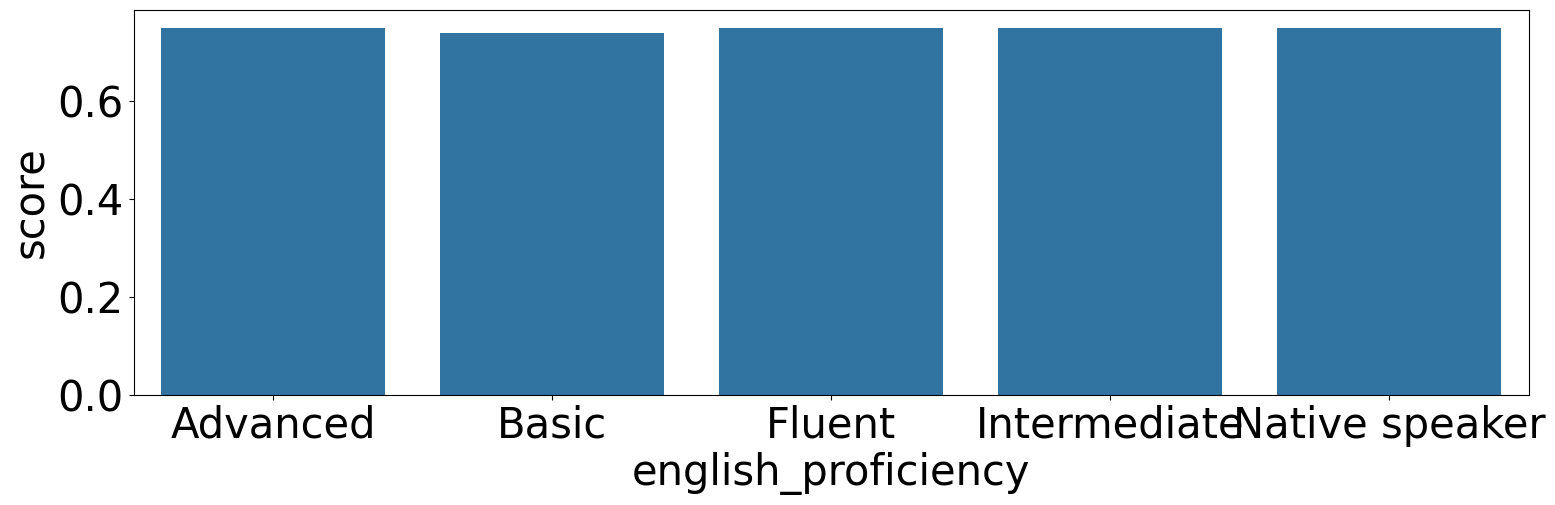

In [13]:
plt.rcParams.update({"font.size": 30})
model_answers = {
    "OLMo": olmo_answers,
}

for model in model_answers:
    model_answers[model]["score"] = 1*(model_answers[model]["answer"] == model_answers[model]["gold_answer"])

for demographic in demographics:
    fig, axes = plt.subplots(1, len(model_answers), sharex=False, sharey=True, figsize=(18, 5))
    for i, model in enumerate(model_answers):
        df = model_answers[model].groupby([demographic])["score"].mean().reset_index()
        sns.barplot(
            data=df,
            x=demographic,
            y="score",
            ax=axes
            #ax=axes[i],
        )